In [1]:
!nvidia-smi

Mon Mar  2 13:40:03 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   40C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [3]:
# Check GPU
import torch
print("GPU Available:", torch.cuda.is_available())

GPU Available: True


In [4]:
!pip install opencv-python matplotlib seaborn

## Import Libraries

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import seaborn as sns

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import confusion_matrix, classification_report

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.19.0


## Load MNIST Dataset

In [6]:
# Load MNIST
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Train shape: (60000, 28, 28)
Test shape: (10000, 28, 28)


## Visualize Some Digits (Sanity Check)

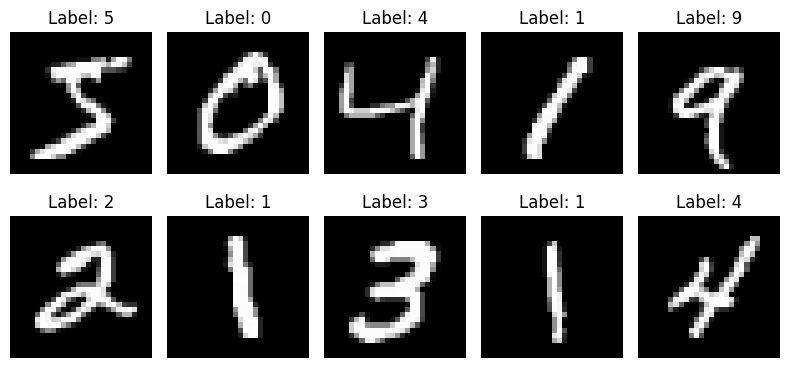

In [7]:
plt.figure(figsize=(8,4))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

## Preprocess MNIST

In [8]:
# Normalize
x_train = x_train / 255.0
x_test = x_test / 255.0

# Reshape to (28,28,1)
x_train = x_train.reshape(-1,28,28,1)
x_test = x_test.reshape(-1,28,28,1)

# One-hot encode labels
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

print("New train shape:", x_train.shape)

New train shape: (60000, 28, 28, 1)


## Build CNN Model

In [9]:
model = models.Sequential([

    layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(10, activation='softmax')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

## Compile Model

In [10]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

## Train Model

In [15]:
history = model.fit(
    x_train, y_train,
    epochs=10,
    batch_size=64,
    validation_data=(x_test, y_test)
)

Epoch 1/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9940 - loss: 0.0178 - val_accuracy: 0.9911 - val_loss: 0.0324
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9949 - loss: 0.0163 - val_accuracy: 0.9939 - val_loss: 0.0237
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9949 - loss: 0.0151 - val_accuracy: 0.9931 - val_loss: 0.0277
Epoch 4/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9952 - loss: 0.0133 - val_accuracy: 0.9942 - val_loss: 0.0273
Epoch 5/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9958 - loss: 0.0118 - val_accuracy: 0.9943 - val_loss: 0.0251
Epoch 6/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9956 - loss: 0.0121 - val_accuracy: 0.9926 - val_loss: 0.0275
Epoch 7/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9967 - loss: 0.0111 - val_accuracy: 0.9937 - val_loss: 0.0243
Epoch 8/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9969 - loss: 0.0089 - val_accuracy: 0.

## Evaluate Model

In [16]:
  # Evaluate on test set
test_loss, test_acc = model.evaluate(x_test, y_test)
print("Test Accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9925 - loss: 0.0311
Test Accuracy: 0.9937000274658203


## Confusion Matrix

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


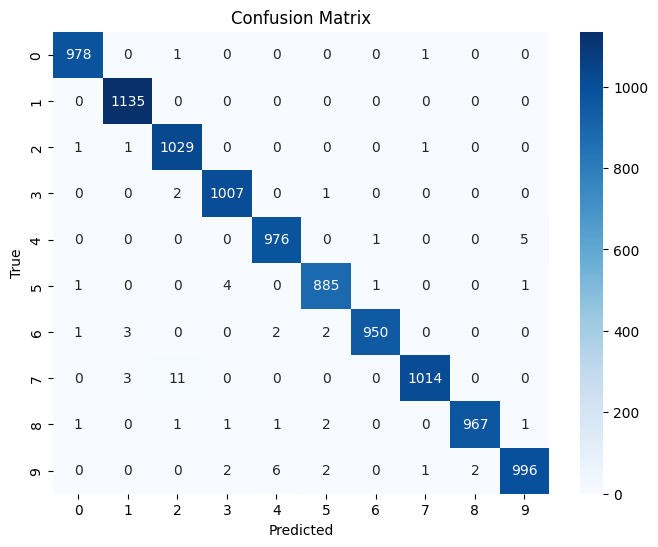

In [17]:
# Get predictions
y_pred = model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

# Confusion matrix
cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

## Save The Model

In [18]:
model.save("digit_cnn_model.h5")
print("Model saved successfully!")

Model saved successfully!


In [19]:
from google.colab import files
files.download("digit_cnn_model.h5")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [20]:
from tensorflow.keras.models import load_model

model = load_model("digit_cnn_model.h5")
print("Model loaded successfully!")

Model loaded successfully!


## 2nd process

##Mount Drive



In [21]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


##Define Correct Path

In [22]:
base_path = "/content/drive/MyDrive/SimplyFI_OCR/ocr_receipts/archive"
images_path = base_path + "/images"

import os
print(os.listdir(images_path))

['10.jpg', '14.jpg', '2.jpg', '6.JPG', '15.jpg', '9.jpg', '8.jpg', '12.jpg', '18.jpg', '16.jpg', '3.jpg', '1.jpg', '17.jpg', '4.jpg', '11.jpg', '7.jpg', '19.jpg', '13.jpg', '5.jpg', '0.jpg']


##Load One Receipt Image

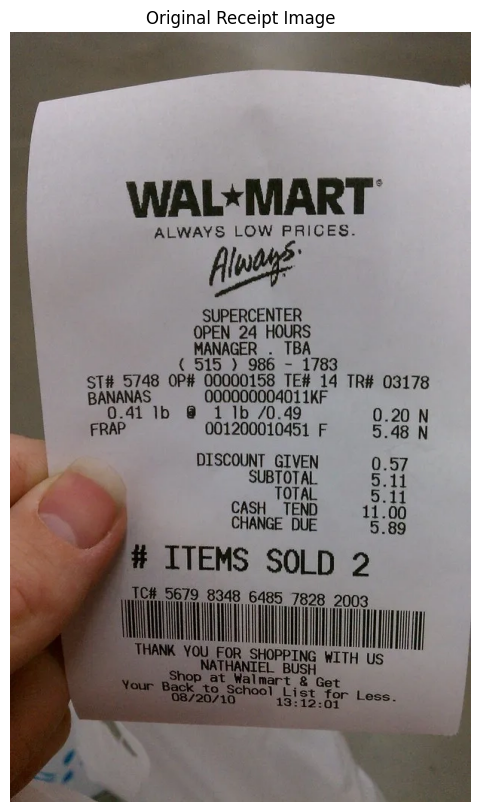

In [23]:
import cv2
import matplotlib.pyplot as plt

# Pick one image
img_path = images_path + "/0.jpg"

# Read image
img = cv2.imread(img_path)

# Convert BGR → RGB for correct display
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6,10))
plt.imshow(img_rgb)
plt.title("Original Receipt Image")
plt.axis("off")
plt.show()

## Region Check using XML

In [63]:
import xml.etree.ElementTree as ET

tree = ET.parse(base_path + "/annotations.xml")
root = tree.getroot()

# See structure
for child in list(root)[:3]:
    print(child.tag, child.attrib)
    for sub in list(child)[:5]:
        print("  ", sub.tag, sub.attrib, sub.text)

version {}
meta {}
   task {} 
      
   dumped {} 2023-09-11 11:15:48.678690+00:00
image {'id': '0', 'name': 'images/0.jpg', 'width': '612', 'height': '1023'}
   polygon {'label': 'receipt', 'source': 'manual', 'occluded': '0', 'points': '39.15,93.53;186.88,67.24;270.27,54.55;332.35,48.66;447.00,54.10;537.19,63.62;593.83,73.13;609.24,67.24;612.00,71.84;612.00,784.65;605.62,862.11;596.10,926.01;589.75,936.89;514.98,931.90;388.54,926.01;196.85,918.31;91.72,913.32;83.56,895.65;72.68,852.60;67.24,800.48;87.64,776.01;118.45,725.71;148.82,680.39;155.61,643.23;153.35,605.16;144.28,587.49;133.41,571.63;108.94,562.56;91.72,561.66;71.78,582.96;50.93,593.38;44.13,521.33;34.16,431.14;25.10,325.10;21.93,270.72;21.93,220.87;25.10,157.43;31.90,110.30', 'z_order': '0'} 
    
   box {'label': 'shop', 'source': 'manual', 'occluded': '0', 'xtl': '153.76', 'ytl': '194.59', 'xbr': '481.86', 'ybr': '245.40', 'rotation': '358.70', 'z_order': '0'} 
      
   box {'label': 'total', 'source': 'manual', 'occlud

In [64]:
import xml.etree.ElementTree as ET
import pandas as pd

tree = ET.parse(base_path + "/annotations.xml")
root = tree.getroot()

records = []
for image_elem in root.iter('image'):
    img_name = image_elem.attrib['name']
    img_id = image_elem.attrib['id']

    for box in image_elem.findall('box'):
        label = box.attrib['label']
        xtl = float(box.attrib['xtl'])
        ytl = float(box.attrib['ytl'])
        xbr = float(box.attrib['xbr'])
        ybr = float(box.attrib['ybr'])

        records.append({
            'image_id': img_id,
            'image_name': img_name,
            'label': label,
            'xtl': xtl, 'ytl': ytl,
            'xbr': xbr, 'ybr': ybr
        })

annotations_df = pd.DataFrame(records)
print(annotations_df.head(20))
print("\nLabel counts:\n", annotations_df['label'].value_counts())

   image_id    image_name      label     xtl     ytl     xbr     ybr
0         0  images/0.jpg       shop  153.76  194.59  481.86  245.40
1         0  images/0.jpg      total  351.28  604.95  525.83  624.91
2         0  images/0.jpg       item  106.25  517.30  555.10  541.35
3         0  images/0.jpg       item  104.28  473.20  556.78  519.90
4         0  images/0.jpg  date_time  214.25  881.94  437.99  894.78
5         1  images/1.jpg      total  144.02  774.05  529.69  790.61
6         1  images/1.jpg       item  131.92  427.14  467.70  445.28
7         1  images/1.jpg       item  133.05  446.09  468.00  464.23
8         1  images/1.jpg       item  135.57  464.57  468.70  482.71
9         1  images/1.jpg       item  134.82  482.46  469.30  500.59
10        1  images/1.jpg       item  137.05  573.04  476.54  610.19
11        1  images/1.jpg       item  134.70  516.99  471.62  535.13
12        1  images/1.jpg       item  135.40  499.11  469.96  517.25
13        1  images/1.jpg       it

##Preprocessing

##Crop and visualize region

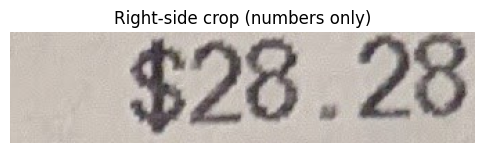

In [138]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def crop_region(image_path, xtl, ytl, xbr, ybr, padding=5):
    img = cv2.imread(image_path)
    if img is None:
        raise ValueError(f"Could not read image: {image_path}")
    h, w = img.shape[:2]

    x1 = max(0, int(xtl) - padding)
    y1 = max(0, int(ytl) - padding)
    x2 = min(w, int(xbr) + padding)
    y2 = min(h, int(ybr) + padding)

    full_crop = img[y1:y2, x1:x2]

    # Take only RIGHT 40% — numbers are always on the right
    crop_w = full_crop.shape[1]
    right_crop = full_crop[:, int(crop_w * 0.65):]

    return right_crop

# Test on image 0 - crop the 'total' region
row = annotations_df[(annotations_df['image_id']=='5') & (annotations_df['label']=='total')].iloc[0]
img_path = base_path + "/" + row['image_name']
crop = crop_region(img_path, row['xtl'], row['ytl'], row['xbr'], row['ybr'])

plt.figure(figsize=(6,2))
plt.imshow(cv2.cvtColor(crop, cv2.COLOR_BGR2RGB))
plt.title("Right-side crop (numbers only)")
plt.axis('off')
plt.show()

## Preprocess and segment digits

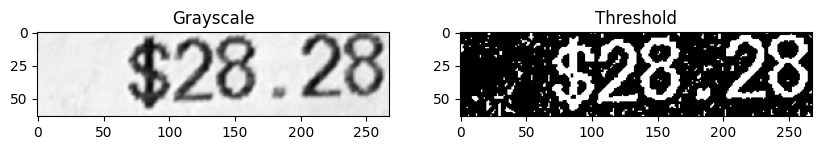

Found 5 digit candidates


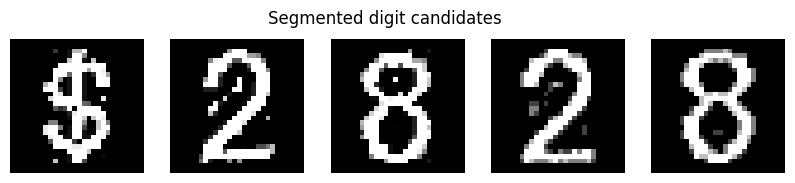

In [139]:
def preprocess_and_segment(crop, debug=False):
    gray = cv2.cvtColor(crop, cv2.COLOR_BGR2GRAY)

    scale = 64 / gray.shape[0]
    new_w = max(1, int(gray.shape[1] * scale))
    gray = cv2.resize(gray, (new_w, 64))

    gray = cv2.GaussianBlur(gray, (3,3), 0)

    thresh = cv2.adaptiveThreshold(
        gray, 255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY_INV, 11, 2
    )

    kernel = np.ones((2,2), np.uint8)
    thresh = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel)

    if debug:
        plt.figure(figsize=(10,2))
        plt.subplot(1,2,1)
        plt.imshow(gray, cmap='gray')
        plt.title('Grayscale')
        plt.subplot(1,2,2)
        plt.imshow(thresh, cmap='gray')
        plt.title('Threshold')
        plt.show()

    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    digit_crops = []
    x_positions = []

    for cnt in contours:
        x, y, w, h = cv2.boundingRect(cnt)
        aspect_ratio = w / float(h)
        area = cv2.contourArea(cnt)

        # Tighter filter — digits are roughly square or taller than wide
        # aspect_ratio < 1.2 removes wide letters like T, A, L
        if area > 20 and h > 15 and 0.1 < aspect_ratio < 1.2:
            digit_crop = thresh[y:y+h, x:x+w]

            size = max(w, h)
            padded = np.zeros((size, size), dtype=np.uint8)
            y_offset = (size - h) // 2
            x_offset = (size - w) // 2
            padded[y_offset:y_offset+h, x_offset:x_offset+w] = digit_crop

            padded = cv2.copyMakeBorder(padded, 4, 4, 4, 4, cv2.BORDER_CONSTANT, value=0)
            resized = cv2.resize(padded, (28, 28))
            digit_crops.append(resized)
            x_positions.append(x)

    if digit_crops:
        sorted_pairs = sorted(zip(x_positions, digit_crops), key=lambda p: p[0])
        digit_crops = [d for _, d in sorted_pairs]

    return digit_crops

# Test with debug=True to see preprocessing
digits = preprocess_and_segment(crop, debug=True)
print(f"Found {len(digits)} digit candidates")

if digits:
    fig, axes = plt.subplots(1, len(digits), figsize=(2*len(digits), 2))
    if len(digits) == 1:
        axes = [axes]
    for i, d in enumerate(digits):
        axes[i].imshow(d, cmap='gray')
        axes[i].axis('off')
    plt.suptitle("Segmented digit candidates")
    plt.show()

##Predict digits

In [140]:
def predict_sequence(digit_crops, model, confidence_threshold=0.6):
    if not digit_crops:
        return "NO_DIGITS", []

    sequence = ""
    confidences = []

    for crop in digit_crops:
        img = crop / 255.0
        img = img.reshape(1, 28, 28, 1)

        pred = model.predict(img, verbose=0)
        digit = np.argmax(pred)
        confidence = float(np.max(pred))

        if confidence < confidence_threshold:
            sequence += "?"
        else:
            sequence += str(digit)

        confidences.append(round(confidence, 2))

    return sequence, confidences

# Test on the total crop
seq, confs = predict_sequence(digits, model)
print("Predicted sequence:", seq)
print("Confidences       :", confs)

Predicted sequence: 52828
Confidences       : [0.85, 1.0, 1.0, 1.0, 1.0]


In [135]:
def crop_all_region(image_path, xtl, ytl, xbr, ybr, label='item', padding=5):
    img = cv2.imread(image_path)
    if img is None:
        raise ValueError(f"Could not read image: {image_path}")
    h, w = img.shape[:2]

    x1 = max(0, int(xtl) - padding)
    y1 = max(0, int(ytl) - padding)
    x2 = min(w, int(xbr) + padding)
    y2 = min(h, int(ybr) + padding)

    full_crop = img[y1:y2, x1:x2]
    crop_w = full_crop.shape[1]

    if label == 'item':
        return full_crop[:, int(crop_w * 0.75):]   # right 35% → price only
    elif label == 'total':
        return full_crop[:, int(crop_w * 0.65):]   # right 35% → amount only
    elif label == 'date_time':
        return full_crop                             # full crop → entire date/time is the value
    else:
        # shop or anything else → skip
        return None

In [141]:
results = []
target_labels = ['total', 'item', 'date_time']  # removed shop

for image_name, group in annotations_df.groupby('image_name'):
    img_path = base_path + "/" + image_name
    image_sequences = []

    for _, box_row in group.iterrows():
        label = box_row['label']
        if label not in target_labels:
            continue

        try:
            crop = crop_all_region(img_path, box_row['xtl'], box_row['ytl'],
                               box_row['xbr'], box_row['ybr'], label=label)  # ← pass label

            if crop is None:  # ← handle None return
                continue

            digit_crops = preprocess_and_segment(crop)
            sequence, confs = predict_sequence(digit_crops, model)

            if sequence and sequence != "NO_DIGITS":
                image_sequences.append({
                    'image'             : image_name,
                    'label'             : label,
                    'predicted_sequence': sequence,
                    'confidences'       : confs,
                    'has_uncertain'     : '?' in sequence
                })

        except Exception as e:
            image_sequences.append({
                'image'             : image_name,
                'label'             : label,
                'predicted_sequence': f"ERROR: {str(e)}",
                'confidences'       : [],
                'has_uncertain'     : True
            })

    results.extend(image_sequences)

results_df = pd.DataFrame(results)
results_df.to_csv("ocr_results.csv", index=False)

# Display with confidences
for img_name, group in results_df.groupby('image'):
    print(f"\n{'='*60}")
    print(f"Image: {img_name}")
    print(f"{'='*60}")
    for _, row in group.iterrows():
        uncertain_flag = " UNCERTAIN" if row['has_uncertain'] else "Ok"
        print(f"  [{row['label'].upper():10s}] → {row['predicted_sequence']}")
        print(f"               Confidences: {row['confidences']} {uncertain_flag}")


Image: images/0.jpg
  [TOTAL     ] → 511
               Confidences: [1.0, 1.0, 1.0] Ok
  [ITEM      ] → 5481
               Confidences: [1.0, 1.0, 1.0, 0.99] Ok
  [ITEM      ] → 0?
               Confidences: [1.0, 0.57]  UNCERTAIN
  [DATE_TIME ] → 08120110113112205011
               Confidences: [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.65, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.6, 1.0, 0.97, 1.0] Ok

Image: images/1.jpg
  [TOTAL     ] → 8631000000
               Confidences: [0.7, 0.99, 1.0, 0.98, 0.88, 0.99, 1.0, 1.0, 0.97, 1.0] Ok
  [ITEM      ] → 204009
               Confidences: [1.0, 1.0, 1.0, 1.0, 1.0, 0.92] Ok
  [ITEM      ] → 1329790
               Confidences: [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.66] Ok
  [ITEM      ] → 30?890
               Confidences: [1.0, 1.0, 0.53, 0.96, 1.0, 0.85]  UNCERTAIN
  [ITEM      ] → 078090
               Confidences: [1.0, 1.0, 1.0, 1.0, 1.0, 1.0] Ok
  [ITEM      ] → 098
               Confidences: [1.0, 1.0, 1.0] Ok
  [ITEM      ] → 39090
   

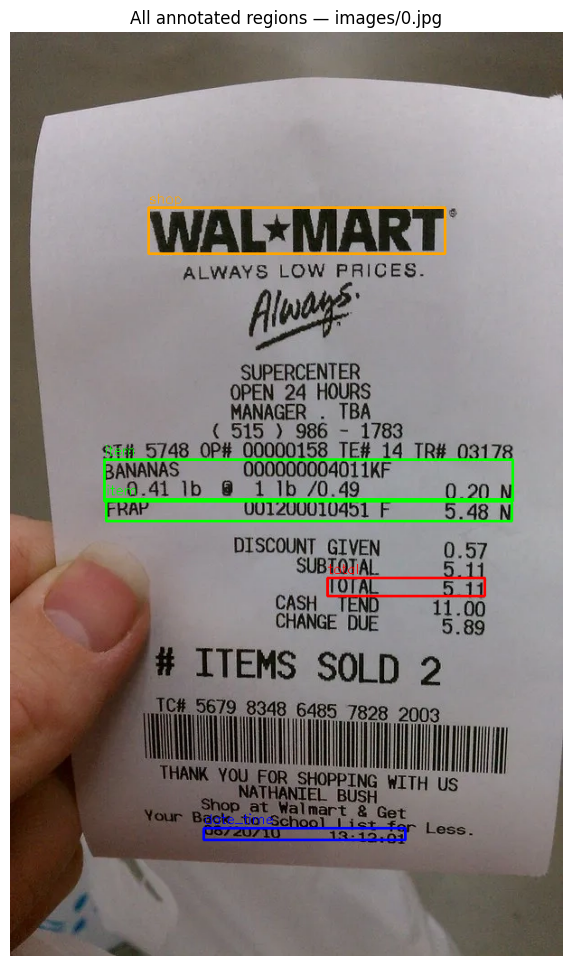

In [142]:
def visualize_all_regions(image_name, annotations_df, base_path):
    img_path = base_path + "/" + image_name
    img = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    group = annotations_df[annotations_df['image_name'] == image_name]
    target_labels = ['total', 'item', 'date_time', 'shop']

    color_map = {
        'total'    : (255, 0, 0),    # red
        'item'     : (0, 255, 0),    # green
        'date_time': (0, 0, 255),    # blue
        'shop'     : (255, 165, 0),  # orange
    }

    img_copy = img_rgb.copy()
    for _, row in group.iterrows():
        if row['label'] not in target_labels:
            continue
        x1, y1, x2, y2 = int(row['xtl']), int(row['ytl']), int(row['xbr']), int(row['ybr'])
        color = color_map.get(row['label'], (128,128,128))
        cv2.rectangle(img_copy, (x1,y1), (x2,y2), color, 2)
        cv2.putText(img_copy, row['label'], (x1, y1-5),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 1)

    plt.figure(figsize=(8, 12))
    plt.imshow(img_copy)
    plt.title(f"All annotated regions — {image_name}")
    plt.axis('off')
    plt.show()

# Visualize image 0
visualize_all_regions('images/0.jpg', annotations_df, base_path)

In [143]:
import pandas as pd

# Round confidences for cleaner display
def format_confidences(conf_list):
    return [round(c, 2) for c in conf_list]

# Prepare clean dataframe for Excel
excel_data = []
for _, row in results_df.iterrows():
    confs = row['confidences'] if isinstance(row['confidences'], list) else []
    avg_conf = round(sum(confs) / len(confs), 3) if confs else 0
    min_conf = round(min(confs), 3) if confs else 0

    excel_data.append({
        'Image'              : row['image'],
        'Label'              : row['label'].upper(),
        'Predicted Sequence' : row['predicted_sequence'],
        'Avg Confidence'     : avg_conf,
        'Min Confidence'     : min_conf,
        'Num Digits'         : len(confs),
        'Has Uncertain'      : 'YES' if row['has_uncertain'] else 'NO',
        'All Confidences'    : str(format_confidences(confs))
    })

excel_df = pd.DataFrame(excel_data)

# Save to Excel with formatting
output_path = "/content/drive/MyDrive/SimplyFI_OCR/ocr_results.xlsx"

with pd.ExcelWriter(output_path, engine='openpyxl') as writer:
    excel_df.to_excel(writer, index=False, sheet_name='OCR Results')

    # Auto-adjust column widths
    worksheet = writer.sheets['OCR Results']
    for col in worksheet.columns:
        max_len = max(len(str(cell.value)) for cell in col if cell.value)
        worksheet.column_dimensions[col[0].column_letter].width = min(max_len + 2, 40)

print(f" Saved to: {output_path}")
print(f"   Total rows: {len(excel_df)}")
print(f"   Uncertain predictions: {excel_df[excel_df['Has Uncertain'] == 'YES'].shape[0]}")
print(f"   Clean predictions: {excel_df[excel_df['Has Uncertain'] == 'NO'].shape[0]}")

 Saved to: /content/drive/MyDrive/SimplyFI_OCR/ocr_results.xlsx
   Total rows: 210
   Uncertain predictions: 56
   Clean predictions: 154
